# Exercise 3

In [21]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [22]:
class Agentstate():
    name: str
    age: str
    skills: list[str]
    final: str

In [ ]:
def first_node(state: Agentstate) -> Agentstate:
    """
    In this node we personalize the name of the user
    """

    state["name"] = f"{state["name"]}, Welcome to the system! "
    return state


def second_node(state: Agentstate) -> Agentstate:
    """
    Here I describe the user's age
    """

    state["age"] = f"You are {state["age"]} years old! "
    return state


def third_node(state:Agentstate) -> Agentstate:
    """This node will list the user's skills in a formatted string""" 
    state["skills"] = f"Yout have skills in: {[item + ',' for item in state["skills"]]}"

    return state

def fourth_node (state:Agentstate) -> Agentstate:
    """
    A feature that brings everything together
    """

    state["final"] = state["name"] + state["age"]+ state["skills"]

    return state

In [24]:
graph = StateGraph(Agentstate)

graph.add_node("node1", first_node)
graph.add_node("node2", second_node)
graph.add_node("node3", third_node)
graph.add_node("node4", fourth_node)

graph.set_entry_point("node1")
graph.add_edge("node1","node2")
graph.add_edge("node2","node3")
graph.add_edge("node3","node4")
graph.set_finish_point("node4")


app = graph.compile()

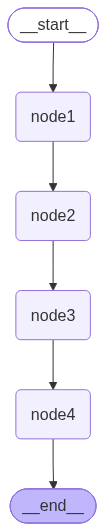

In [25]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [26]:
result = app.invoke({"name": "Linda", "age": 31, "skills":["Python", "Machine Learning", "LangGraph"]})

In [27]:
result["final"]

"Linda, Welcome to the system! You are 31 years old! Yout have skills in: ['Python,', 'Machine Learning,', 'LangGraph,']"